# 📊 Statistische Analyse & Visualisierung — Immobilienpreise Niedersachsen
**Agiles Programmierprojekt – intoCODE / InterGeeks**

Dieses Notebook deckt alle Pflichtbereiche der Aufgabendefinition ab:
1. Datenbereinigung & Datenqualität
2. Deskriptive Statistik und Datenverständnis
3. Einflussanalyse
4. Zusammenhangsanalyse
5. Hypothesentests und Inferenzstatistik

---
> **Hinweis zu Data Leakage:** `obj_purchasePrice_per_qm` ist direkt aus der Zielvariable berechnet (Preis / Fläche) → darf **nicht** als Feature im ML verwendet werden. Sie wird hier nur für die deskriptive Analyse genutzt.

## 0. Imports & Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import sqlite3
import warnings
warnings.filterwarnings("ignore")

# ── Globaler Plot-Stil ──────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

# ── Output-Ordner für Präsentationsgrafiken ─────────────────────────────────
OUTPUT_DIR = "plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_fig(fig, name):
    """Speichert Grafik als PNG (150 dpi) für PowerPoint-Export."""
    fig.savefig(f"{OUTPUT_DIR}/{name}.png", dpi=150, bbox_inches="tight")
    print(f"  💾 Gespeichert: {OUTPUT_DIR}/{name}.png")

print("✅ Setup abgeschlossen.")

✅ Setup abgeschlossen.


---
## 1. Daten laden
Die Daten werden aus der MySQL/SQLite-Datenbank geladen.
Stelle sicher, dass `../data/db/prices.db` erreichbar ist.

In [3]:
# ── Dynamischer DB-Pfad (passt sich automatisch an die Ordnertiefe an) ───────
current_dir = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
db_filename = os.path.normpath(os.path.join(current_dir, "../data/db/prices.db"))
table_name  = "house_prices"

print(f"🗄️  Verbinde mit Datenbank: {db_filename}")

conn   = sqlite3.connect(db_filename)
df_raw = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

print(f"✅ Daten geladen! Rohdaten-Shape: {df_raw.shape}")
df_raw.head()

🗄️  Verbinde mit Datenbank: c:\Users\Yasser Nourallah\Desktop\HSH Weiterbildung\Abschluss Projekt\hoky_immobilien\data\db\prices.db
✅ Daten geladen! Rohdaten-Shape: (5055, 20)


,obj_regio1,obj_newlyConst,obj_yearConstructed,obj_firingTypes,obj_cellar,obj_houseNumber,obj_livingSpace,geo_krs,obj_condition,obj_street,geo_plz,obj_noRooms,obj_telekomInternetProductAvailable,obj_barrierFree,obj_regio3,obj_livingSpaceRange,obj_telekomUploadSpeed,obj_telekomDownloadSpeed,obj_purchasePrice,obj_purchasePrice_per_qm
0,Niedersachsen,n,2013.0,gas,n,NaN,170.0,Verden_Kreis,well_kept,NaN,28832.0,6.0,1.0,n,Achim,5.0,40.0,100.0,549000.0,3229.411765
1,Niedersachsen,n,1909.0,oil,n,NaN,170.0,Hannover_Kreis,well_kept,NaN,30900.0,6.0,1.0,n,Wedemark,5.0,2.4,16.0,460000.0,2705.882353
2,Niedersachsen,n,1969.0,district_heating,y,NaN,116.0,Celle_Kreis,well_kept,NaN,29353.0,6.0,1.0,n,other,2.0,10.0,50.0,148500.0,1280.172414
3,Niedersachsen,y,2020.0,NaN,n,NaN,133.0,Helmstedt_Kreis,first_time_use,NaN,38364.0,4.0,1.0,n,Schöningen,3.0,40.0,100.0,248400.0,1867.669173
4,Niedersachsen,n,2000.0,district_heating,y,NaN,136.0,Wolfsburg,well_kept,NaN,38446.0,5.0,1.0,y,other,3.0,2.4,16.0,369000.0,2713.235294


---
## 2. Datenbereinigung & Datenqualitätsbewertung
*(Aufgabendefinition: Identifikation von Ausreißern und fehlenden Werten, Bewertung der Datenqualität)*

### 2.1 Fehlende Werte analysieren

🔍 Fehlende Werte je Spalte:
                                     fehlend  prozent (%)
obj_street                              4583         90.7
obj_houseNumber                         4583         90.7
obj_condition                           1558         30.8
obj_telekomDownloadSpeed                 983         19.4
obj_telekomUploadSpeed                   983         19.4
obj_firingTypes                          799         15.8
obj_telekomInternetProductAvailable      326          6.4
  💾 Gespeichert: plots/01_fehlende_werte_perfect.png


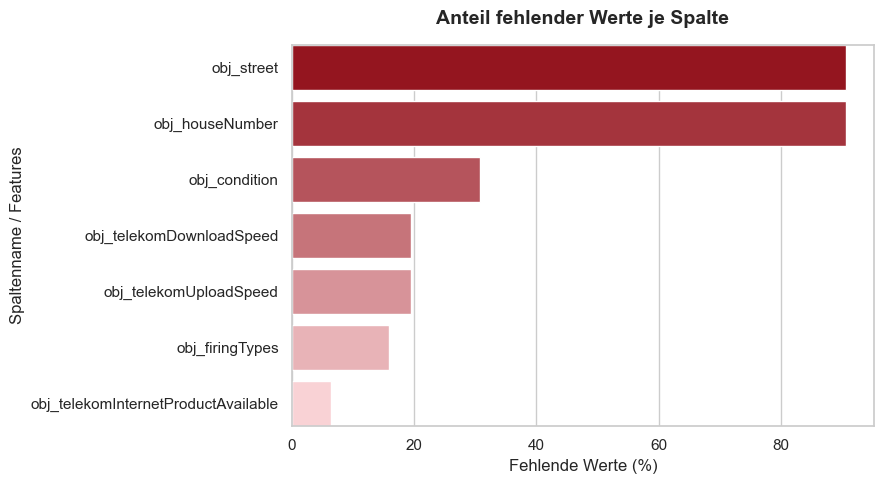

In [66]:
# 1️⃣ حساب القيم المفقودة ونسبتها المئوية
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_table = pd.DataFrame({"fehlend": missing, "prozent (%)": missing_pct})
missing_table = missing_table[missing_table["fehlend"] > 0]

print("🔍 Fehlende Werte je Spalte:")
print(missing_table)

# 2️⃣ تجهيز المخطط البياني والتدرج اللوني للمشروع
fig, ax = plt.subplots(figsize=(9, 5))

dark_red = "#a9000d"   # اللون الأساسي لمشروعك
light_red = "#ffccd0"  # الدرجة الفاتحة المتناسقة
n_colors = len(missing_table)

# إنشاء التدرج بناءً على عدد الأعمدة التي تحتوي على قيم مفقودة
custom_palette = sns.color_palette(sns.blend_palette([dark_red, light_red], n_colors=n_colors))

# 3️⃣ رسم المخطط الأفقي بالألوان الجديدة
sns.barplot(x=missing_table["prozent (%)"], y=missing_table.index,
            hue=missing_table.index, ax=ax, palette=custom_palette, legend=False)

# تحسين العناوين والمحاور لتظهر بشكل احترافي بالكامل
ax.set_title("Anteil fehlender Werte je Spalte", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Fehlende Werte (%)", fontsize=12)
ax.set_ylabel("Spaltenname / Features", fontsize=12)

# ── 🚨 إزالة الهوامش عند الصفر تماماً لالتصاق الأعمدة بالحافة ──────────
ax.set_xlim(left=0)
ax.margins(y=0)
# ─────────────────────────────────────────────────────────────────────────────

plt.tight_layout()
save_fig(fig, "01_fehlende_werte_perfect")
plt.show()

**Entscheidungen zu fehlenden Werten:**
- `obj_houseNumber`, `obj_street`, `obj_regio1`: >90% fehlend oder konstant → **entfernen**
- `obj_firingTypes`, `obj_condition`: fehlend → Kategorie **„unknown"** (keine Daten ≠ keine Heizung)
- `obj_telekomUploadSpeed`, `obj_telekomDownloadSpeed`: fehlend → **0** + Flag-Spalte `obj_hasInternetData`

### 2.2 Bereinigung durchführen

In [5]:
df = df_raw.copy()  # استخدام المتغير الخام الصحيح بأخذ نسخة منه

# ── Konstante / nicht-informative Spalten entfernen ─────────────────────────
df = df.drop(columns=["obj_regio1"], errors="ignore")

# ── Adressspalten entfernen (>90 % fehlend, nicht für ML relevant) ──────────
df = df.drop(columns=["obj_houseNumber", "obj_street"], errors="ignore")

# ── Unplausible Zeilen entfernen (Match mit clean_data.ipynb) ────────────────
n_before_unplausible = len(df)

df = df[df['obj_livingSpace'] > 0]
df = df[df['obj_purchasePrice'] > 0]
df = df[df["obj_purchasePrice"] >= 5000] 

print(f"Entfernte Zeilen (Unplausibel): {n_before_unplausible - len(df)}  (livingSpace=0 oder Preis < 5000 €)")

# ── إعادة حساب سعر المتر المربع بعد التنظيف ──────────────────────────────────
df['obj_purchasePrice_per_qm'] = df['obj_purchasePrice'] / df['obj_livingSpace']

# ── حذف الصفوف التي تحتوي على قيم مفقودة بدلاً من unknown ──────────────────────
n_before_dropna = len(df)

categorical_cols_to_drop = ["obj_firingTypes", "obj_condition"]
df = df.dropna(subset=categorical_cols_to_drop)

df["obj_telekomInternetProductAvailable"] = df["obj_telekomInternetProductAvailable"].fillna("NotAvailable").astype(str)

print(f"Entfernte Zeilen (wegen Missing Values): {n_before_dropna - len(df)}")

# ── Numerische fehlende Werte (Internet-Geschwindigkeit) ────────────────────
df["obj_hasInternetData"]        = df["obj_telekomUploadSpeed"].notna().astype(int)
df["obj_telekomUploadSpeed"]     = df["obj_telekomUploadSpeed"].fillna(0)
df["obj_telekomDownloadSpeed"]   = df["obj_telekomDownloadSpeed"].fillna(0)

# ── Heizungstypen von 60 → 6 Gruppen zusammenfassen (بدون unknown) ──────────
def group_firing_type(val):
    v = str(val).lower()
    if "gas"           in v: return "gas"
    if "oil"           in v: return "oil"
    if "district"      in v or "local_heating" in v: return "fernwaerme"
    if any(x in v for x in ["solar","geotherm","environmental","pellet","wood"]): return "erneuerbar"
    if "electricity"   in v: return "strom"
    return "sonstige"

df["firingType_grouped"] = df["obj_firingTypes"].apply(group_firing_type)

print(f"\n✅ Bereinigte Shape: {df.shape}")
print(f"Verbleibende fehlende Werte: {df.isnull().sum().sum()}")
print("\n📊 Verteilung der Heizungstypen:")
print(df["firingType_grouped"].value_counts())

Entfernte Zeilen (Unplausibel): 23  (livingSpace=0 oder Preis < 5000 €)
Entfernte Zeilen (wegen Missing Values): 1933

✅ Bereinigte Shape: (3099, 19)
Verbleibende fehlende Werte: 0

📊 Verteilung der Heizungstypen:
firingType_grouped
gas           2222
oil            613
strom          105
erneuerbar      96
fernwaerme      56
sonstige         7
Name: count, dtype: int64


### 2.3 Ausreißer-Bereinigung nach Quantilen (je Landkreis)

📊 رسم البيانات VOR Bereinigung:
  💾 Gespeichert: plots/00_outlier_VOR_bereinigung.png


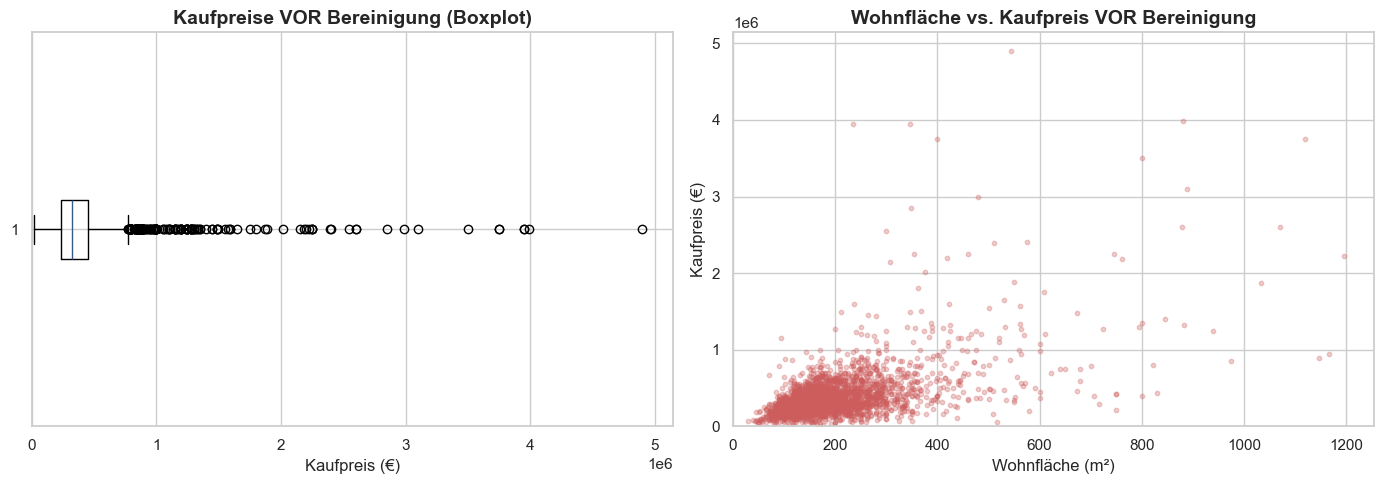


✅ Shape nach Ausreißer-Bereinigung: (2990, 19)

📊 رسم البيانات NACH Bereinigung:
  💾 Gespeichert: plots/00_outlier_NACH_bereinigung.png


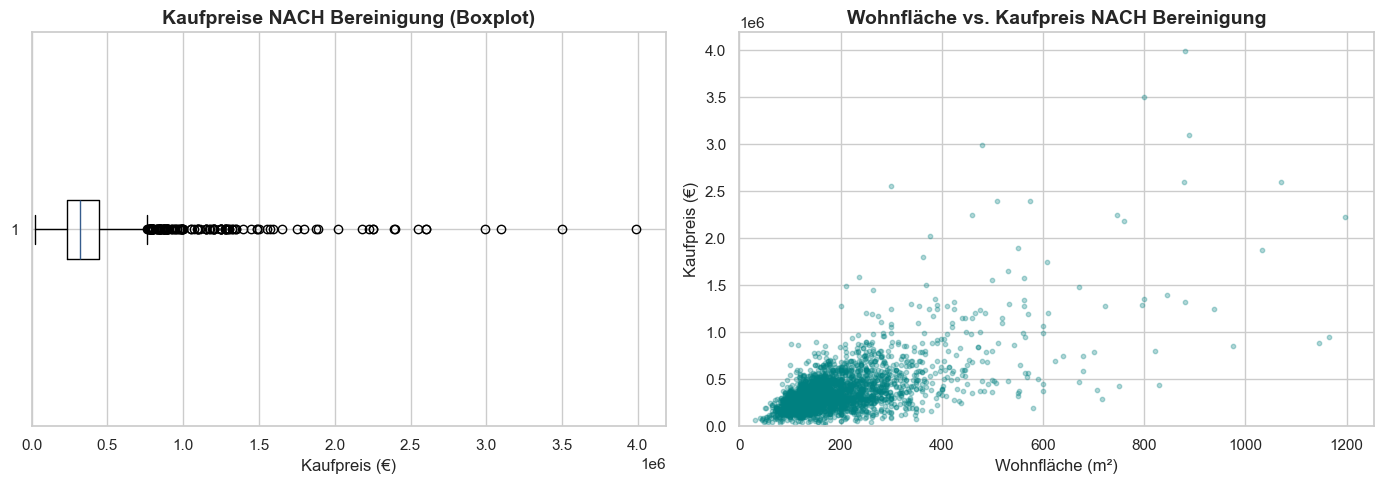

💾 Gespeichert: price_cleaned_for_analysis.csv
Maximaler Kaufpreis vor der Bereinigung: 4900000.0 €
Maximaler Kaufpreis nach der Bereinigung: 3990000.0 €
Anzahl der vollständig gelöschten Zeilen: 2065


In [6]:
# 1️⃣ أولاً: رسم المخططات للبيانات قبل التنظيف (Vor der Bereinigung) - مع تعديل المحاور
print("📊 رسم البيانات VOR Bereinigung:")
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# مخطط الصندوق قبل التنظيف
ax1.boxplot(df["obj_purchasePrice"], vert=False)
ax1.set_title("Kaufpreise VOR Bereinigung (Boxplot)")
ax1.set_xlabel("Kaufpreis (€)")
ax1.set_xlim(left=0) 
ax1.margins(y=0)

# مخطط التشتت قبل التنظيف
ax2.scatter(df["obj_livingSpace"], df["obj_purchasePrice"], alpha=0.3, color="indianred", s=10)
ax2.set_title("Wohnfläche vs. Kaufpreis VOR Bereinigung")
ax2.set_xlabel("Wohnfläche (m²)")
ax2.set_ylabel("Kaufpreis (€)")

# ── 🚨 إلغاء الفراغات البيضاء عند الأصفار تماماً في رسمة VOR ──────────────────
ax2.set_xlim(left=0)   # جعل محور X يبدأ من الصفر تماماً
ax2.set_ylim(bottom=0) # جعل محور Y يبدأ من الصفر تماماً
ax2.margins(x=0, y=0)  # إلغاء الهوامش التلقائية
# ─────────────────────────────────────────────────────────────────────────────

plt.tight_layout()
save_fig(fig1, "00_outlier_VOR_bereinigung") # حفظ رسمة قبل التنظيف
plt.show()


# 2️⃣ ثانياً: تعريف دالة التنظيف المحلية بناءً على الـ Quantiles وتشغيلها
def remove_outliers_by_quantile(df, col="obj_purchasePrice_per_qm",
                                lower_pct=0.01, upper_pct=0.99, group_col="geo_krs"):
    """Entfernt die extremsten 1% nach oben und unten – getrennt je Landkreis."""
    parts = []
    for _, sub in df.groupby(group_col):
        lo = sub[col].quantile(lower_pct)
        hi = sub[col].quantile(upper_pct)
        parts.append(sub[(sub[col] >= lo) & (sub[col] <= hi)])
    return pd.concat(parts)

# تنفيذ التنظيف الفعلي على الداتا وتحديث الـ df
df = remove_outliers_by_quantile(df)
print(f"\n✅ Shape nach Ausreißer-Bereinigung: {df.shape}\n")


# 3️⃣ ثالثاً: رسم المخططات للبيانات بعد التنظيف (Nach der Bereinigung) - مع تعديل المحاور
print("📊 رسم البيانات NACH Bereinigung:")
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

# مخطط الصندوق بعد التنظيف
ax3.boxplot(df["obj_purchasePrice"], vert=False)
ax3.set_title("Kaufpreise NACH Bereinigung (Boxplot)")
ax3.set_xlabel("Kaufpreis (€)")
ax3.set_xlim(left=0) 
ax3.margins(y=0)

# مخطط التشتت بعد التنظيف
ax4.scatter(df["obj_livingSpace"], df["obj_purchasePrice"], alpha=0.3, color="teal", s=10)
ax4.set_title("Wohnfläche vs. Kaufpreis NACH Bereinigung")
ax4.set_xlabel("Wohnfläche (m²)")
ax4.set_ylabel("Kaufpreis (€)")

# ── 🚨 إلغاء الفراغات البيضاء عند الأصفار تماماً في رسمة NACH ──────────────────
ax4.set_xlim(left=0)   # جعل محور X يبدأ من الصفر تماماً
ax4.set_ylim(bottom=0) # جعل محور Y يبدأ من الصفر تماماً
ax4.margins(x=0, y=0)  # إلغاء الهوامش التلقائية
# ─────────────────────────────────────────────────────────────────────────────

plt.tight_layout()
save_fig(fig2, "00_outlier_NACH_bereinigung") # حفظ رسمة بعد التنظيف
plt.show()


# 4️⃣ رابعاً: حفظ البيانات المنظفة كملف CSV لاستخدامها لاحقاً
df.to_csv("price_cleaned_for_analysis.csv", index=False)
print("💾 Gespeichert: price_cleaned_for_analysis.csv")

# Maximale Preise vor und nach der Bereinigung sowie die Anzahl der gelöschten Zeilen ausgeben
print(f"Maximaler Kaufpreis vor der Bereinigung: {df_raw['obj_purchasePrice'].max()} €")
print(f"Maximaler Kaufpreis nach der Bereinigung: {df['obj_purchasePrice'].max()} €")
print(f"Anzahl der vollständig gelöschten Zeilen: {len(df_raw) - len(df)}")

---
## 3. Deskriptive Statistik und Datenverständnis
*(Aufgabendefinition: Berechnung von Lage- und Streuungsmaßen, Analyse der Verteilungen, Erstellung geeigneter Visualisierungen)*

### 3.1 Lage- und Streuungsmaße (Lageparameter & Streuungsmaße)

In [7]:
LEAKAGE_COL = "obj_purchasePrice_per_qm"  # nur für deskriptive Analyse, NICHT als ML-Feature!
numeric_cols = [
    "obj_purchasePrice",
    LEAKAGE_COL,
    "obj_livingSpace",
    "obj_noRooms",
    "obj_yearConstructed",
]

desc = df[numeric_cols].describe().T
desc["median"]   = df[numeric_cols].median()
desc["variance"] = df[numeric_cols].var()
desc["IQR"]      = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
desc["skewness"] = df[numeric_cols].skew()   # Schiefe: >0 = rechtsschief

print("📊 Lage- und Streuungsmaße (Überblick):")
print(desc[["mean","median","std","variance","IQR","min","max","skewness"]].round(2).to_string())

📊 Lage- und Streuungsmaße (Überblick):
                               mean     median        std      variance        IQR       min         max  skewness
obj_purchasePrice         374048.77  322000.00  265240.53  7.035254e+10  210000.00  24750.00  3990000.00      4.53
obj_purchasePrice_per_qm    2046.69    1952.79     905.15  8.192935e+05    1209.07    145.59     8578.43      0.98
obj_livingSpace              192.57     165.00     108.88  1.185573e+04      98.00     30.00     1196.00      3.18
obj_noRooms                    6.53       6.00       3.28  1.074000e+01       3.50      1.00       40.00      2.77
obj_yearConstructed         1966.99    1974.00      49.33  2.433800e+03      41.00   1496.00     2021.00     -2.92


### 3.2 Verteilung der Zielvariable Kaufpreis

  💾 Gespeichert: plots/02_verteilung_kaufpreis_perfect_final.png


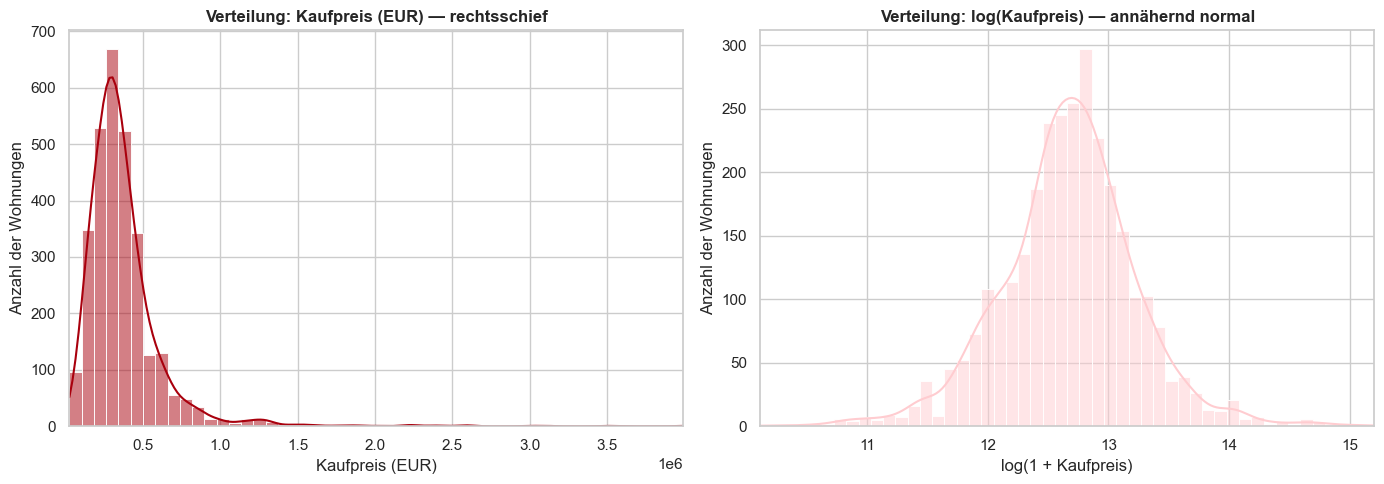

📊 Analyse der Datenverteilung (Skewness):
--------------------------------------------------
  Schiefe Original:          4.53
  Schiefe log-transformiert: -0.06
  → Log-Transformation empfohlen für lineare Modelle!
--------------------------------------------------


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# الهوية اللونية الموحدة للمشروع
dark_red = "#a9000d"   # اللون الأساسي الغامق
light_red = "#ffccd0"  # الدرجة الفاتحة المتناسقة

# ── 1️⃣ المخطط الأول: التوزيع التكراري الأصلي باللون الأساسي الغامق ───────────
sns.histplot(df["obj_purchasePrice"], bins=50, kde=True, ax=axes[0], color=dark_red, 
             kde_kws={"cut": 0}) 
axes[0].set_title("Verteilung: Kaufpreis (EUR) — rechtsschief", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Kaufpreis (EUR)")
axes[0].set_ylabel("Anzahl der Wohnungen")

# ضبط الحدود البرمجية الصارمة والالتحام مع الصفر
axes[0].set_xlim(df["obj_purchasePrice"].min(), df["obj_purchasePrice"].max())
axes[0].set_ylim(bottom=0)
axes[0].margins(x=0, y=0)


# ── 2️⃣ المخطط الثاني: التوزيع اللوغاريتمي بالدرجة الفاتحة للمشروع ─────────────
log_prices = np.log1p(df["obj_purchasePrice"])

sns.histplot(log_prices, bins=50, kde=True, ax=axes[1], color=light_red, 
             kde_kws={"cut": 0}) 
axes[1].set_title("Verteilung: log(Kaufpreis) — annähernd normal", fontsize=12, fontweight='bold')
axes[1].set_xlabel("log(1 + Kaufpreis)")
axes[1].set_ylabel("Anzahl der Wohnungen")

# ضبط الحدود البرمجية الصارمة والالتحام مع الصفر
axes[1].set_xlim(log_prices.min(), log_prices.max())
axes[1].set_ylim(bottom=0)
axes[1].margins(x=0, y=0)  
# ─────────────────────────────────────────────────────────────────────────────

plt.tight_layout()
save_fig(fig, "02_verteilung_kaufpreis_perfect_final")
plt.show()

# طباعة قيم الالتواء (Skewness) في الـ Terminal بشكل مرتب ومميز
print("📊 Analyse der Datenverteilung (Skewness):")
print("-" * 50)
print(f"  Schiefe Original:          {df['obj_purchasePrice'].skew():.2f}")
print(f"  Schiefe log-transformiert: {log_prices.skew():.2f}")
print("  → Log-Transformation empfohlen für lineare Modelle!") 
print("-" * 50)

### 3.3 Verteilung weiterer numerischer Variablen

  💾 Gespeichert: plots/03_verteilungen_uebersicht_perfect.png


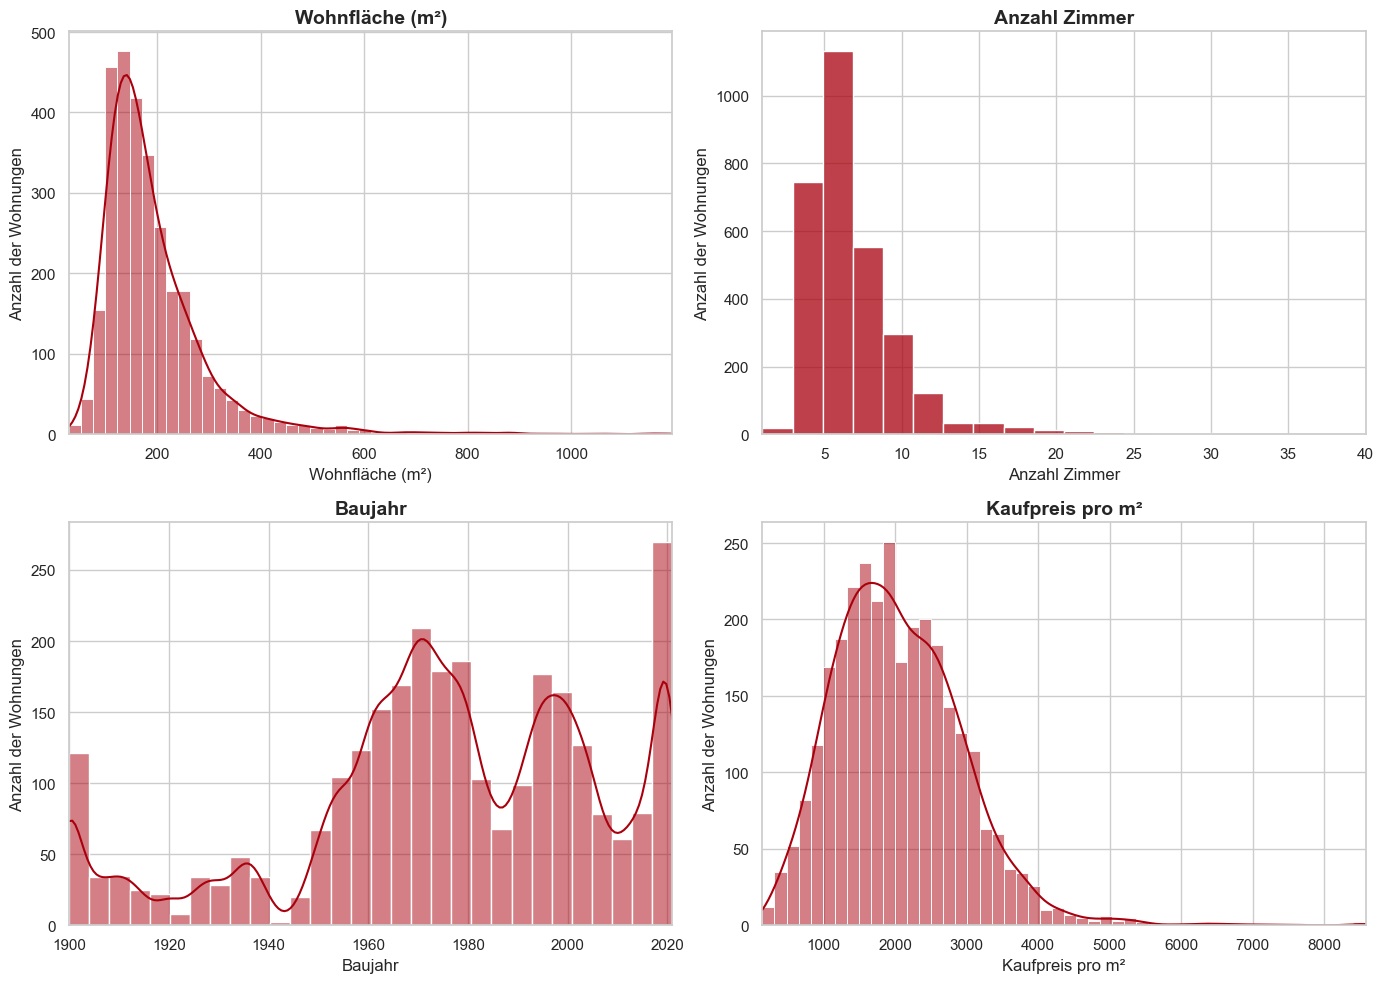

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# اللون الموحد الجديد للمشروع
PROJECT_COLOR = "#a9000d"

# ── 1️⃣ المخطط الأول: المساحة المعيشية (Wohnfläche) ───────────────────────────
sns.histplot(df["obj_livingSpace"], bins=50, kde=True, ax=axes[0,0], color=PROJECT_COLOR, kde_kws={"cut": 0})
axes[0,0].set_title("Wohnfläche (m²)")
axes[0,0].set_xlabel("Wohnfläche (m²)")
axes[0,0].set_ylabel("Anzahl der Wohnungen")
axes[0,0].set_xlim(df["obj_livingSpace"].min(), df["obj_livingSpace"].max())
axes[0,0].set_ylim(bottom=0)
axes[0,0].margins(x=0, y=0)


# ── 2️⃣ المخطط الثاني: عدد الغرف (Anzahl Zimmer) ───────────────────────────────
sns.histplot(df["obj_noRooms"], bins=20, kde=False, ax=axes[0,1], color=PROJECT_COLOR)
axes[0,1].set_title("Anzahl Zimmer")
axes[0,1].set_xlabel("Anzahl Zimmer")
axes[0,1].set_ylabel("Anzahl der Wohnungen")
axes[0,1].set_xlim(df["obj_noRooms"].min(), df["obj_noRooms"].max())
axes[0,1].set_ylim(bottom=0)
axes[0,1].margins(x=0, y=0)


# ── 3️⃣ المخطط الثالث: سنة البناء مع جعل المنحنى دقيقاً جداً ──────────────────
df_filtered_year = df[df["obj_yearConstructed"] >= 1900]

sns.histplot(df_filtered_year["obj_yearConstructed"], bins=30, kde=True, 
             ax=axes[1,0], color=PROJECT_COLOR, kde_kws={"cut": 0, "bw_adjust": 0.4})
axes[1,0].set_title("Baujahr")
axes[1,0].set_xlabel("Baujahr")
axes[1,0].set_ylabel("Anzahl der Wohnungen")
axes[1,0].set_xlim(1900, df_filtered_year["obj_yearConstructed"].max())
axes[1,0].set_ylim(bottom=0)
axes[1,0].margins(x=0, y=0)


# ── 4️⃣ المخطط الرابع: سعر المتر المربع (Kaufpreis pro m²) ────────────────────
sns.histplot(df[LEAKAGE_COL], bins=50, kde=True, ax=axes[1,1], color=PROJECT_COLOR, kde_kws={"cut": 0})
axes[1,1].set_title("Kaufpreis pro m²")
axes[1,1].set_xlabel("Kaufpreis pro m²")
axes[1,1].set_ylabel("Anzahl der Wohnungen")
axes[1,1].set_xlim(df[LEAKAGE_COL].min(), df[LEAKAGE_COL].max())
axes[1,1].set_ylim(bottom=0)
axes[1,1].margins(x=0, y=0)

# ─────────────────────────────────────────────────────────────────────────────

plt.tight_layout()
save_fig(fig, "03_verteilungen_uebersicht_perfect")
plt.show()

### 3.4 Ausreißer-Identifikation (1.5 × IQR Regel)

  💾 Gespeichert: plots/04_boxplots_ausreisser_perfect.png


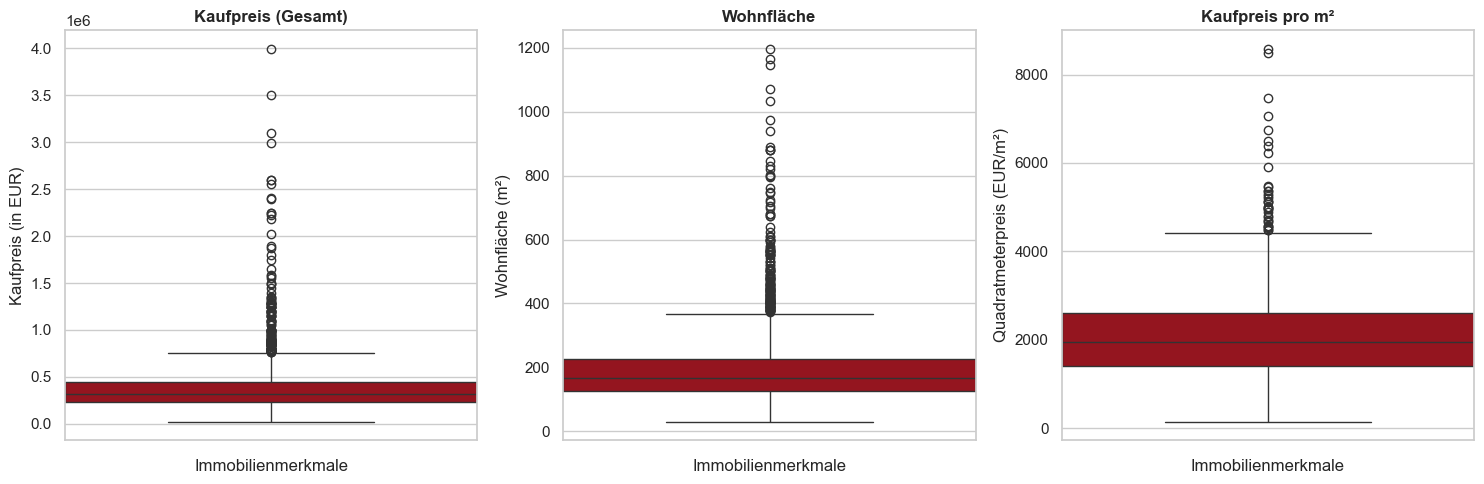

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

titles_and_labels = {
    "obj_purchasePrice": {"title": "Kaufpreis (Gesamt)", "ylabel": "Kaufpreis (in EUR)"},
    "obj_livingSpace": {"title": "Wohnfläche", "ylabel": "Wohnfläche (m²)"},
    LEAKAGE_COL: {"title": "Kaufpreis pro m²", "ylabel": "Quadratmeterpreis (EUR/m²)"}
}

PROJECT_COLOR = "#a9000d"
columns = ["obj_purchasePrice", "obj_livingSpace", LEAKAGE_COL]

for ax, col in zip(axes, columns):
    sns.boxplot(y=df[col], ax=ax, color=PROJECT_COLOR)
    
    info = titles_and_labels.get(col, {"title": col, "ylabel": col})
    ax.set_title(info["title"], fontsize=12, fontweight='bold')
    ax.set_ylabel(info["ylabel"])
    ax.set_xlabel("Immobilienmerkmale")
    
    # ── ✅ الحل: حذف الـ ylim وترك المحور يتنفس بحرية لمنع الانضغاط ──
    ax.margins(x=0) 
    # ─────────────────────────────────────────────────────────────────

plt.tight_layout()
save_fig(fig, "04_boxplots_ausreisser_perfect")
plt.show()

### 3.5 Kategoriale Variablen — Häufigkeitsverteilungen

  💾 Gespeichert: plots/05_kategoriale_verteilungen.png


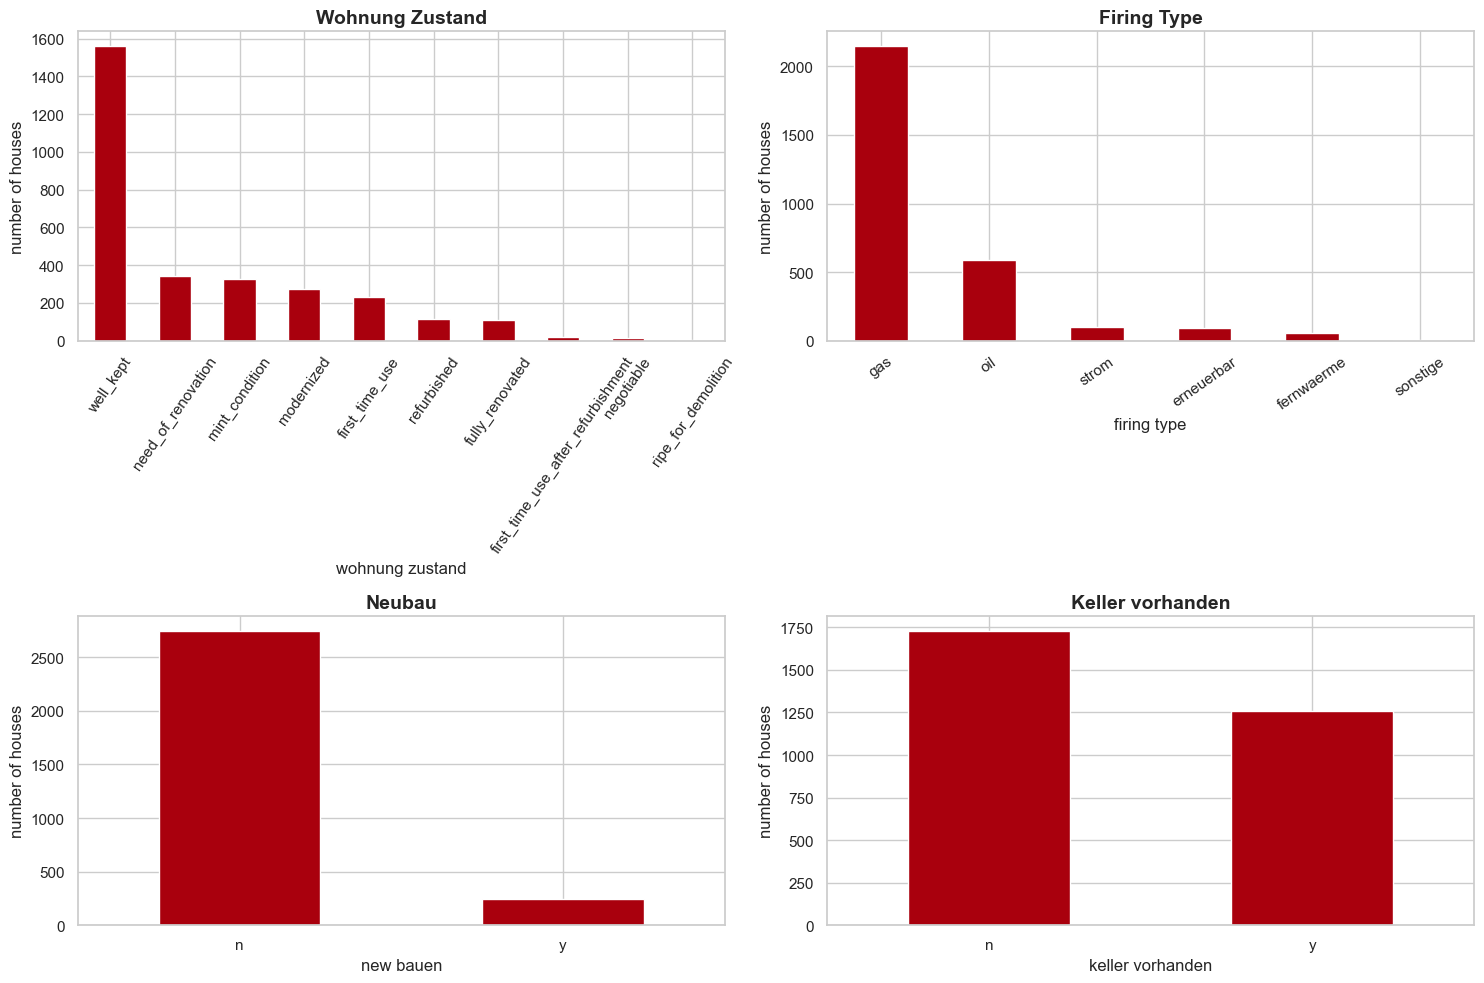

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# اللون المعتمد والموحد للمشروع
project_color = "#a9000d"

# 1. المخطط الأول: Wohnung Zustand
obj_cond_counts = df["obj_condition"].value_counts().drop("unknown", errors="ignore")
obj_cond_counts.plot(kind="bar", ax=axes[0, 0], color=project_color)
axes[0, 0].set_title("Wohnung Zustand")
axes[0, 0].set_xlabel("wohnung zustand")
axes[0, 0].set_ylabel("number of houses")
axes[0, 0].tick_params(axis="x", rotation=55)

# 2. المخطط الثاني: Firing Type
firing_counts = df["firingType_grouped"].value_counts().drop("unknown", errors="ignore")
firing_counts.plot(kind="bar", ax=axes[0, 1], color=project_color)
axes[0, 1].set_title("Firing Type")
axes[0, 1].set_xlabel("firing type")
axes[0, 1].set_ylabel("number of houses")
axes[0, 1].tick_params(axis="x", rotation=35)

# 3. المخطط الثالث: Neubau
df["obj_newlyConst"].value_counts().plot(kind="bar", ax=axes[1, 0], color=project_color)
axes[1, 0].set_title("Neubau")
axes[1, 0].set_xlabel("new bauen")
axes[1, 0].set_ylabel("number of houses")
axes[1, 0].tick_params(axis="x", rotation=0)

# 4. المخطط الرابع: Keller vorhanden
df["obj_cellar"].value_counts().plot(kind="bar", ax=axes[1, 1], color=project_color)
axes[1, 1].set_title("Keller vorhanden")
axes[1, 1].set_xlabel("keller vorhanden")
axes[1, 1].set_ylabel("number of houses")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.tight_layout()
save_fig(fig, "05_kategoriale_verteilungen")
plt.show()


### 3.6 Regionale Verteilung — Top 15 Landkreise nach Inseratanzahl

  💾 Gespeichert: plots/06_top_landkreise_perfect.png


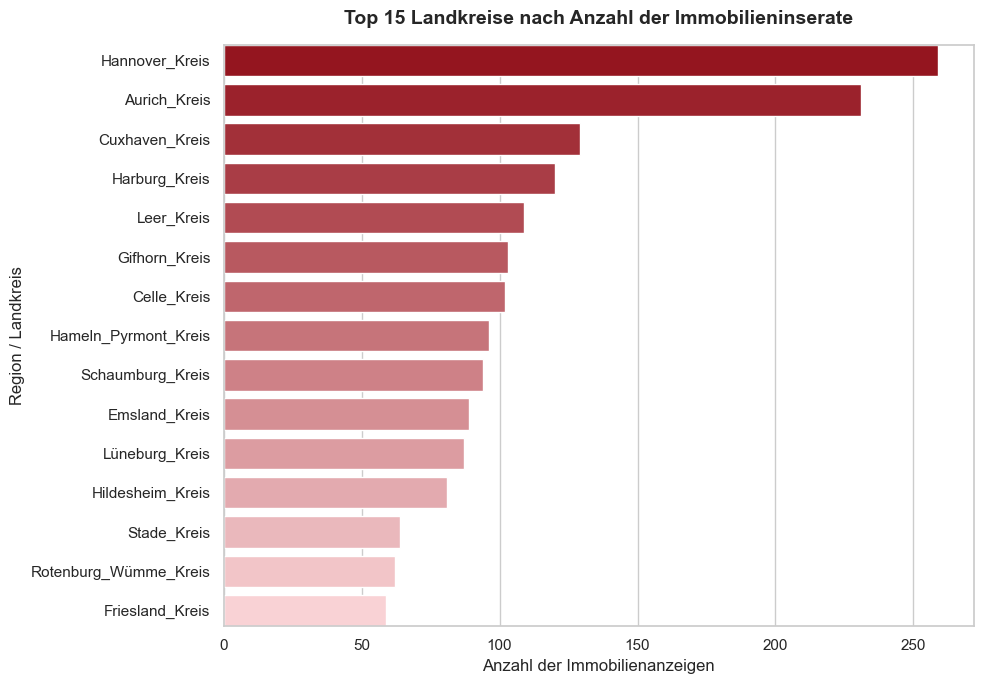

In [46]:
fig, ax = plt.subplots(figsize=(10, 7))

# 1️⃣ استخراج أعلى 15 مقاطعة من الداتا
top_krs = df["geo_krs"].value_counts().head(15)

# 2️⃣ صناعة التدرج اللوني المضمون من الأغمق إلى الأفتح
# سنحدد نقطة البداية (أحمر غامق جداً) ونقطة النهاية (أحمر فاتح) لإنشاء التدرج
dark_red = "#a9000d"   # درجة غامقة جداً من الأحمر
light_red = "#ffccd0"  # درجة فاتحة وناعمة من الأحمر

# إنشاء لوحة تدرج تحتوي على 15 لوناً فريداً متناسقاً
custom_palette = sns.color_palette(sns.blend_palette([dark_red, light_red], n_colors=15))

# 3️⃣ رسم المخطط باستخدام التدرج الجديد
sns.barplot(x=top_krs.values, y=top_krs.index,
            hue=top_krs.index, ax=ax, palette=custom_palette, legend=False)

# 4️⃣ العناوين والمحاور المقروءة بالألمانية
ax.set_title("Top 15 Landkreise nach Anzahl der Immobilieninserate", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Anzahl der Immobilienanzeigen", fontsize=12)
ax.set_ylabel("Region / Landkreis", fontsize=12)

# ── 🚨 إزالة الفراغات البيضاء تماماً ───────────────────────────────────────
ax.set_xlim(left=0)
ax.margins(y=0)
# ─────────────────────────────────────────────────────────────────────────────

plt.tight_layout()
save_fig(fig, "06_top_landkreise_perfect")
plt.show()

**Interpretation (Deskriptive Statistik):**
- Kaufpreis und Wohnfläche sind stark **rechtsschief** → Log-Transformation für ML empfohlen
- Ca. **6 %** der Kaufpreise und **5.7 %** der Wohnflächen liegen außerhalb des 1.5×IQR
- `obj_condition` fehlt bei ~31 % der Datensätze → als „unknown" behandelt, kein Datenverlust
- Regionale Konzentration: Die meisten Inserate kommen aus wenigen Großlandkreisen

---
## 4. Einflussanalyse
*(Aufgabendefinition: Definition der Zielvariable, Analyse des Einflusses einzelner Variablen, gemeinsame Wirkung, wichtigste Einflussfaktoren)*

**Zielvariable:** `obj_purchasePrice` (Kaufpreis in EUR)

**Einflussvariablen:** `obj_livingSpace`, `obj_yearConstructed`, `obj_noRooms`, `obj_condition`, `geo_krs`, `obj_newlyConst`, `obj_cellar`, `firingType_grouped`

### 4.1 Einfluss des Objektzustands auf Preis/m² (Boxplot)

  💾 Gespeichert: plots/07_einfluss_zustand_perfect.png


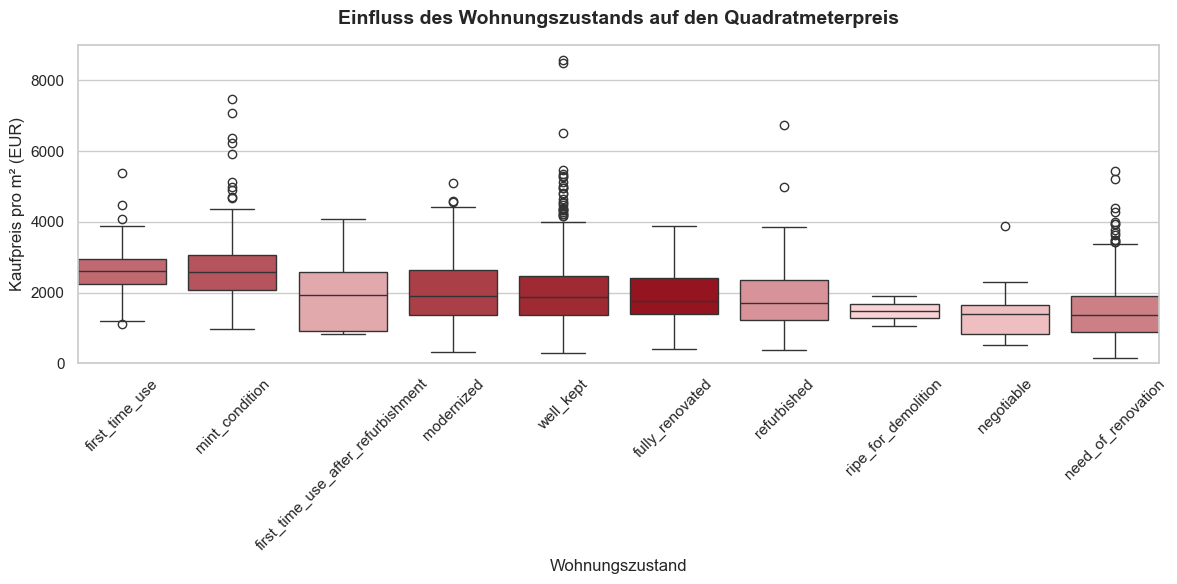

In [54]:
fig, ax = plt.subplots(figsize=(12, 6))

# اللون الموحد الخاص بمشروعك
PROJECT_COLOR = "#a9000d"

# 1️⃣ استبعاد قيمة "Unknown" من البيانات قبل البدء بالترتيب والرسم
df_filtered_condition = df[df["obj_condition"] != "Unknown"]

# 2️⃣ حساب الترتيب التنازلي بناءً على الـ median بعد الاستبعاد
order = (df_filtered_condition.groupby("obj_condition")[LEAKAGE_COL]
         .median().sort_values(ascending=False).index)

# 3️⃣ إنشاء تدرج لوني مخصص من الأغمق إلى الأفتح بناءً على عدد العناصر الفريدة
n_colors = len(order)
dark_red = "#a9000d"   # الدرجة الداكنة الأساسية لمشروعك
light_red = "#ffccd0"  # الدرجة الفاتحة والناعمة
custom_palette = sns.color_palette(sns.blend_palette([dark_red, light_red], n_colors=n_colors))

# 4️⃣ رسم المخطط الصندوقي (Boxplot) بالبيانات المنقحة والألوان الجديدة
sns.boxplot(data=df_filtered_condition, x="obj_condition", y=LEAKAGE_COL,
            order=order, hue="obj_condition", legend=False,
            ax=ax, palette=custom_palette)

# 5️⃣ تحديث العناوين والمحاور للغة ألمانية مفهومة وقريبة من خياراتك
ax.set_title("Einfluss des Wohnungszustands auf den Quadratmeterpreis", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Wohnungszustand", fontsize=12)
ax.set_ylabel("Kaufpreis pro m² (EUR)", fontsize=12)

ax.tick_params(axis="x", rotation=45)

# ── 🚨 التعديل المطلوب: إلغاء الهامش السفلي تماماً والبدء من الصفر المطلق ──
ax.set_ylim(bottom=0)  # التحام تام مع خط الصفر السفلي لمنع الفراغات الزائدة
ax.margins(x=0)        # إلغاء الهوامش الجانبية للأفق
# ─────────────────────────────────────────────────────────────────────────────

plt.tight_layout()
save_fig(fig, "07_einfluss_zustand_perfect")
plt.show()

### 4.2 Einfluss Neubau-Status auf Preis/m²

  💾 Gespeichert: plots/08_einfluss_neubau_perfect.png


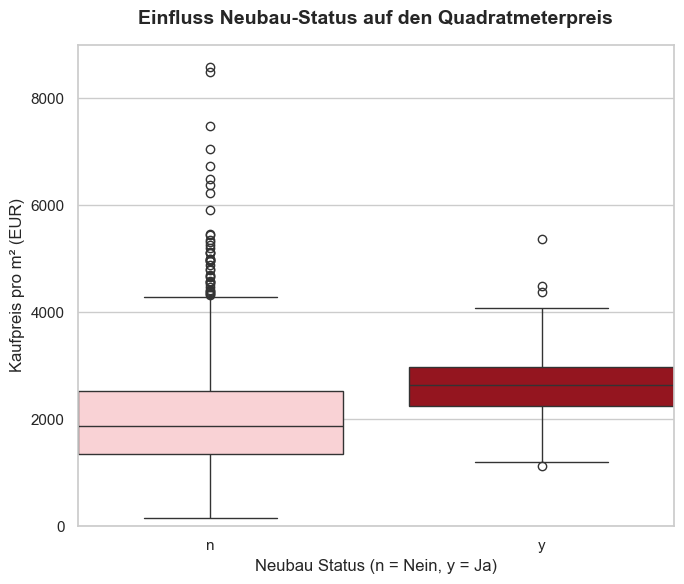

📊 Statistische Kennzahlen nach Neubau-Status:
--------------------------------------------------
                  mean  median    std
obj_newlyConst                       
n               1995.0  1880.0  909.0
y               2628.0  2633.0  613.0
--------------------------------------------------


In [56]:
fig, ax = plt.subplots(figsize=(7, 6))

# الألوان المتناسقة المعتمدة لديك
dark_red = "#a9000d"   
light_red = "#ffccd0"  
custom_palette = [light_red, dark_red]

# رسم المخطط الصندوقي
sns.boxplot(data=df, x="obj_newlyConst", y=LEAKAGE_COL,
            hue="obj_newlyConst", legend=False, ax=ax, palette=custom_palette)

# تحسين العناوين والمحاور
ax.set_title("Einfluss Neubau-Status auf den Quadratmeterpreis", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Neubau Status (n = Nein, y = Ja)", fontsize=12)
ax.set_ylabel("Kaufpreis pro m² (EUR)", fontsize=12)

# ── 🚨 التعديل المطلوب: إلغاء الهامش السفلي والالتحام مع الصفر تماماً ──────
ax.set_ylim(bottom=0)  # جعل المحور يبدأ من الصفر المطلق بدون فراغ بيضاوي سفلي
ax.margins(x=0)        # إلغاء الهوامش الجانبية للأفق
# ─────────────────────────────────────────────────────────────────────────────

plt.tight_layout()
save_fig(fig, "08_einfluss_neubau_perfect")
plt.show()

# طباعة التحليل العددي
print("📊 Statistische Kennzahlen nach Neubau-Status:")
print("-" * 50)
print(df.groupby("obj_newlyConst")[LEAKAGE_COL]
      .agg(["mean", "median", "std"]).round(0))
print("-" * 50)

### 4.3 Einfluss des Baujahrs auf Preis/m²

  💾 Gespeichert: plots/09_einfluss_baujahr.png


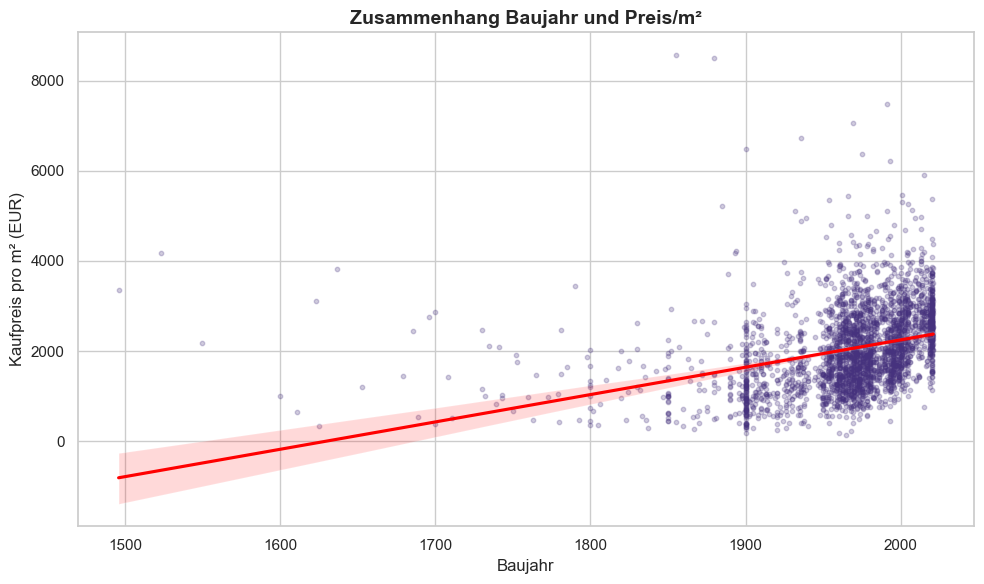

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=df, x="obj_yearConstructed", y=LEAKAGE_COL,
            scatter_kws={"alpha": 0.25, "s": 10},
            line_kws={"color": "red"}, ax=ax)
ax.set_title("Zusammenhang Baujahr und Preis/m²")
ax.set_xlabel("Baujahr")
ax.set_ylabel("Kaufpreis pro m² (EUR)")
plt.tight_layout()
save_fig(fig, "09_einfluss_baujahr")
plt.show()

### 4.4 Einfluss der Wohnfläche auf den Gesamtpreis

  💾 Gespeichert: plots/10_einfluss_wohnflaeche.png


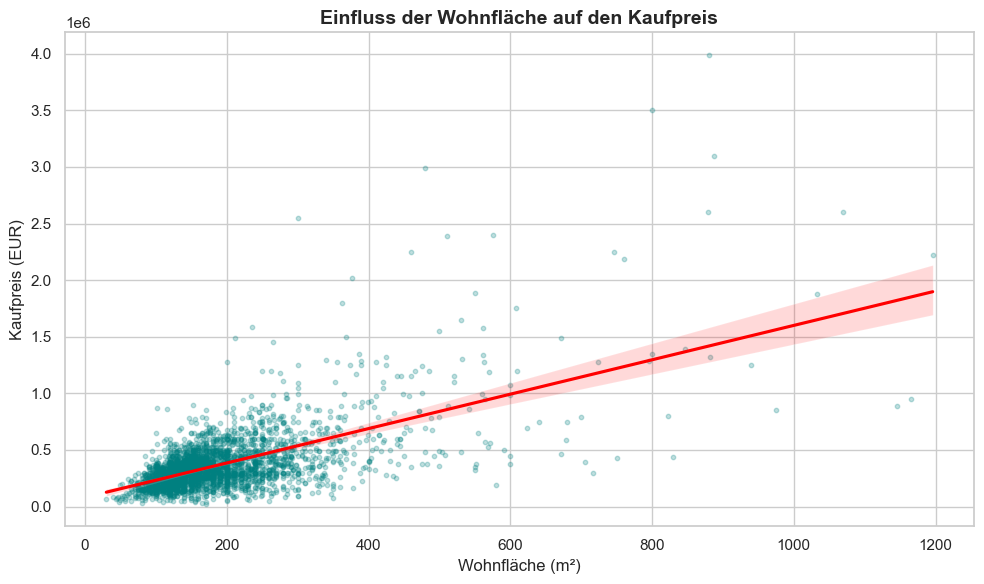

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=df, x="obj_livingSpace", y="obj_purchasePrice",
            scatter_kws={"alpha": 0.25, "color": "teal", "s": 10},
            line_kws={"color": "red"}, ax=ax)
ax.set_title("Einfluss der Wohnfläche auf den Kaufpreis")
ax.set_xlabel("Wohnfläche (m²)")
ax.set_ylabel("Kaufpreis (EUR)")
plt.tight_layout()
save_fig(fig, "10_einfluss_wohnflaeche")
plt.show()

### 4.5 Regionale Preisunterschiede: Top 10 teuerste vs. günstigste Landkreise

  💾 Gespeichert: plots/11_regionaler_einfluss_perfect.png


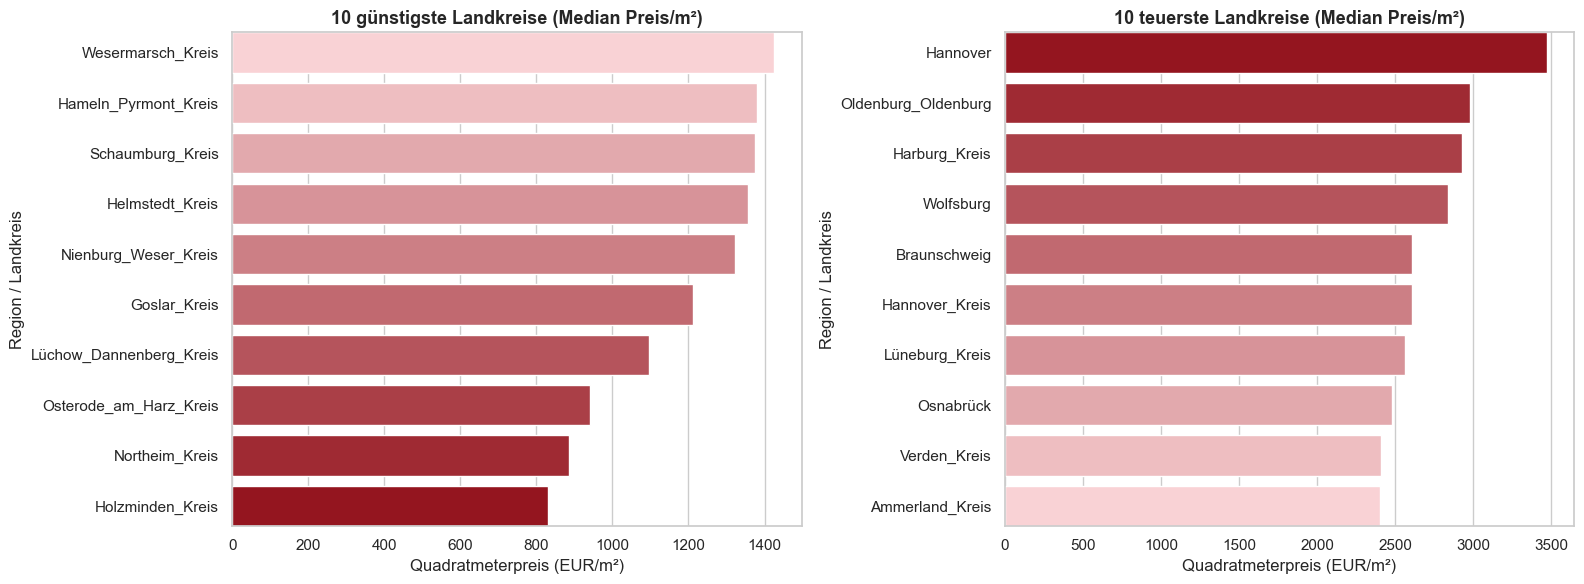

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# حساب القيم الوسيطية وترتيبها تصاعدياً
krs_median = df.groupby("geo_krs")[LEAKAGE_COL].median().sort_values()

# الألوان المعتمدة للتدرج
dark_red = "#a9000d"
light_red = "#ffccd0"

# ── 1️⃣ المخطط الأول: 10 günstigste Landkreise (عكس الترتيب) ───────────────
# جلب أول 10 مقاطعات وعكسها [[::-1]] لتصبح الأرخص في الأعلى تماماً
cheapest_10 = krs_median.head(10)[::-1]

# التدرج: بما أننا عكسنا البيانات، الأرخص في الأعلى يأخذ الفاتح، والأسفل يأخذ الأغمق
palette_cheap = sns.color_palette(sns.blend_palette([light_red, dark_red], n_colors=10))

sns.barplot(x=cheapest_10.values, y=cheapest_10.index, ax=axes[0], palette=palette_cheap, hue=cheapest_10.index, legend=False)
axes[0].set_title("10 günstigste Landkreise (Median Preis/m²)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Quadratmeterpreis (EUR/m²)")
axes[0].set_ylabel("Region / Landkreis")

# إلغاء الهوامش والالتصاق بالصفر
axes[0].set_xlim(left=0)
axes[0].margins(y=0)


# ── 2️⃣ المخطط الثاني: 10 teuerste Landkreise (بدون تعديل ترتيب) ───────────
# جلب آخر 10 مقاطعات وعكسها فقط ليكون الأغلى في الأعلى برسمة الـ barplot
expensive_10 = krs_median.tail(10)[::-1]

# التدرج: الأعلى سعراً (في الأعلى) يأخذ الأغمق، ويتجه للفاتح في الأسفل
palette_expensive = sns.color_palette(sns.blend_palette([dark_red, light_red], n_colors=10))

sns.barplot(x=expensive_10.values, y=expensive_10.index, ax=axes[1], palette=palette_expensive, hue=expensive_10.index, legend=False)
axes[1].set_title("10 teuerste Landkreise (Median Preis/m²)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Quadratmeterpreis (EUR/m²)")
axes[1].set_ylabel("Region / Landkreis")

# إلغاء الهوامش والالتصاق بالصفر
axes[1].set_xlim(left=0)
axes[1].margins(y=0)

# ─────────────────────────────────────────────────────────────────────────────

plt.tight_layout()
save_fig(fig, "11_regionaler_einfluss_perfect")
plt.show()

### 4.6 Gemeinsame Wirkung der Einflussvariablen (Feature Importance via Random Forest)

🏆 Wichtigste Einflussfaktoren auf den Kaufpreis (gemeinsame Wirkung):
     Einflussfaktor  Wichtigkeit (%)
    obj_livingSpace            50.83
obj_yearConstructed            18.77
            geo_krs            14.34
        obj_noRooms            11.00
      obj_condition             5.07
  💾 Gespeichert: plots/12_feature_importance_perfect.png


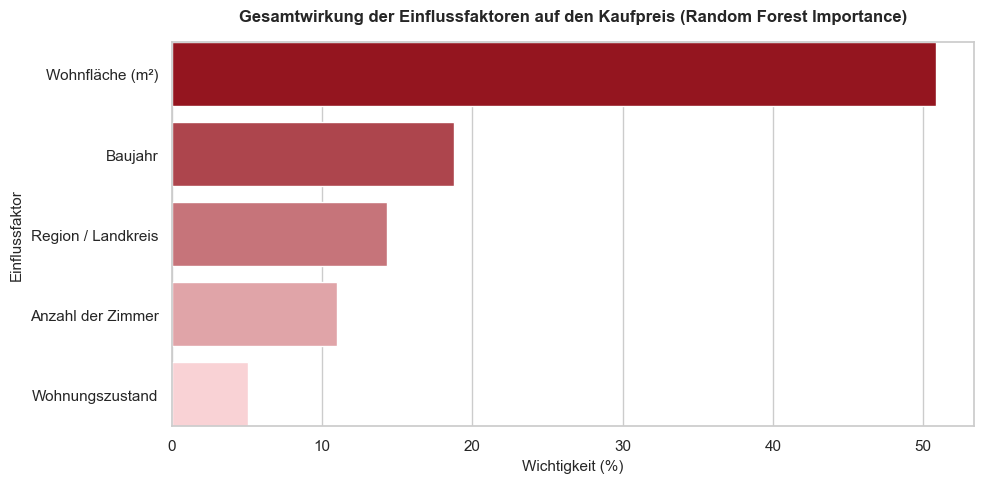

In [64]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder

# 1️⃣ تجهيز البيانات وتدريب الـ Random Forest
features = ["obj_livingSpace", "obj_yearConstructed", "obj_noRooms", "obj_condition", "geo_krs"]
X_imp = df[features].copy()
y_imp = df["obj_purchasePrice"]

enc = OrdinalEncoder()
X_imp[["obj_condition", "geo_krs"]] = enc.fit_transform(X_imp[["obj_condition", "geo_krs"]])

rf_imp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_imp.fit(X_imp, y_imp)

# 2️⃣ حساب الأهمية النسبية وترتيبها تنازلياً
importance_df = pd.DataFrame({
    "Einflussfaktor": features,
    "Wichtigkeit (%)": rf_imp.feature_importances_ * 100
}).sort_values("Wichtigkeit (%)", ascending=False)

print("🏆 Wichtigste Einflussfaktoren auf den Kaufpreis (gemeinsame Wirkung):")
print(importance_df.round(2).to_string(index=False))

# 3️⃣ رسم المخطط البياني بالتدرج اللوني الموحد للمشروع
fig, ax = plt.subplots(figsize=(10, 5))

# قاموس لتغيير المسميات البرمجية على المحور إلى مسميات ألمانية مقروءة واحترافية
clean_labels = {
    "obj_livingSpace": "Wohnfläche (m²)",
    "geo_krs": "Region / Landkreis",
    "obj_yearConstructed": "Baujahr",
    "obj_condition": "Wohnungszustand",
    "obj_noRooms": "Anzahl der Zimmer"
}
# تطبيق المسميات الجديدة في جدول الرسم البياني
importance_df["Einflussfaktor_clean"] = importance_df["Einflussfaktor"].map(clean_labels)

# إعداد التدرج اللوني بناءً على لون المشروع #a9000d (من الأغمق للأفتح)
dark_red = "#a9000d"   # اللون الأساسي للمشروع
light_red = "#ffccd0"  # الدرجة الفاتحة المتناسقة
n_colors = len(features)
custom_palette = sns.color_palette(sns.blend_palette([dark_red, light_red], n_colors=n_colors))

# رسم المخطط الأفقي بالألوان الجديدة والمسميات النظيفة
sns.barplot(data=importance_df, x="Wichtigkeit (%)", y="Einflussfaktor_clean",
            hue="Einflussfaktor_clean", legend=False, palette=custom_palette, ax=ax)

# تحسين العناوين والمحاور
ax.set_title("Gesamtwirkung der Einflussfaktoren auf den Kaufpreis (Random Forest Importance)", fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Wichtigkeit (%)", fontsize=11)
ax.set_ylabel("Einflussfaktor", fontsize=11)

# ── 🚨 إزالة الهوامش عند الصفر تماماً لالتصاق الأعمدة بالحافة ──────────
ax.set_xlim(left=0)
ax.margins(y=0)
# ─────────────────────────────────────────────────────────────────────────────

plt.tight_layout()
save_fig(fig, "12_feature_importance_perfect")
plt.show()

**Interpretation (Einflussanalyse):**
- **Wohnfläche** ist der stärkste einzelne numerische Einflussfaktor
- **Landkreis (geo_krs)** erklärt gemeinsam mit anderen Variablen den größten Anteil der Preisvarianz
- **Neubau-Status** hat einen signifikanten Aufpreis (~+40 % auf den Median-Preis/m²)
- Das Baujahr zeigt eine **nicht-lineare** Beziehung: Gebäude aus den 1950-70ern günstiger, neuere und historische teurer

---
## 5. Zusammenhangsanalyse
*(Aufgabendefinition: geeignete Zusammenhangsmaße, Stärke und Richtung, Beziehungen zwischen Variablen)*

### 5.1 Pearson-Korrelation (numerisch ↔ numerisch)

  💾 Gespeichert: plots/13_pearson_heatmap.png


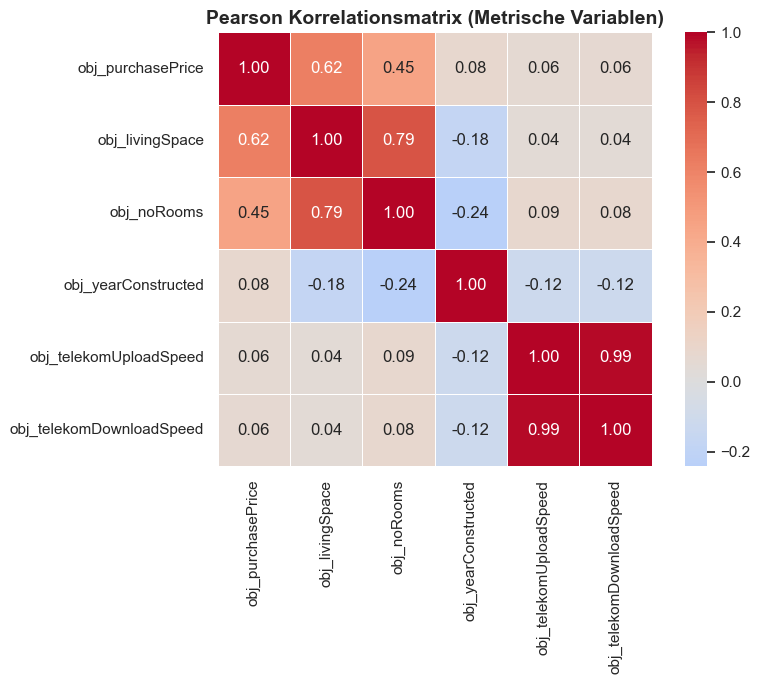


📊 Korrelation mit Zielvariable 'obj_purchasePrice':
  obj_livingSpace                    : r = +0.623  (stark, ↑ Positiv)
  obj_noRooms                        : r = +0.450  (moderat, ↑ Positiv)
  obj_yearConstructed                : r = +0.084  (schwach, ↑ Positiv)
  obj_telekomDownloadSpeed           : r = +0.064  (schwach, ↑ Positiv)
  obj_telekomUploadSpeed             : r = +0.063  (schwach, ↑ Positiv)


In [19]:
numeric_features = [
    "obj_purchasePrice","obj_livingSpace","obj_noRooms",
    "obj_yearConstructed","obj_telekomUploadSpeed","obj_telekomDownloadSpeed"
]

pearson_matrix = df[numeric_features].corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pearson_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Pearson Korrelationsmatrix (Metrische Variablen)")
plt.tight_layout()
save_fig(fig, "13_pearson_heatmap")
plt.show()

# Richtung und Stärke der Zusammenhänge mit der Zielvariable
print("\n📊 Korrelation mit Zielvariable 'obj_purchasePrice':")
target_corr = pearson_matrix["obj_purchasePrice"].drop("obj_purchasePrice").sort_values(key=abs, ascending=False)
for col, coef in target_corr.items():
    richtung = "↑ Positiv" if coef > 0 else "↓ Negativ"
    staerke  = "stark" if abs(coef)>0.5 else "moderat" if abs(coef)>0.3 else "schwach"
    print(f"  {col:35s}: r = {coef:+.3f}  ({staerke}, {richtung})")

### 5.2 Multikollinearitätsprüfung

In [20]:
print("🔗 Prüfung auf Multikollinearität zwischen Einflussvariablen:")
pairs = [
    ("obj_livingSpace","obj_noRooms"),
    ("obj_telekomUploadSpeed","obj_telekomDownloadSpeed"),
]
for col1, col2 in pairs:
    r = df[col1].corr(df[col2])
    warn = "⚠️  Multikollinearität!" if abs(r) > 0.6 else "✅ OK"
    print(f"  {col1} ↔ {col2}: r = {r:.3f}  {warn}")

🔗 Prüfung auf Multikollinearität zwischen Einflussvariablen:
  obj_livingSpace ↔ obj_noRooms: r = 0.795  ⚠️  Multikollinearität!
  obj_telekomUploadSpeed ↔ obj_telekomDownloadSpeed: r = 0.990  ⚠️  Multikollinearität!


### 5.3 Eta² — kategorial ↔ numerisch (ANOVA-basiert)

In [21]:
def eta_squared(df, cat_col, num_col):
    """Eta²: Anteil der durch die Gruppe erklärten Varianz (0–1)."""
    groups      = [g[num_col].dropna().values for _, g in df.groupby(cat_col) if len(g) > 1]
    grand_mean  = df[num_col].mean()
    ss_between  = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups)
    ss_total    = ((df[num_col] - grand_mean)**2).sum()
    f_stat, p   = stats.f_oneway(*groups)
    return ss_between/ss_total, f_stat, p

print("📊 Eta² (Effektstärke: kategorialer Einfluss auf Preis/m²):")
for cat in ["obj_condition","firingType_grouped","obj_newlyConst","obj_cellar"]:
    eta2, F, p = eta_squared(df, cat, LEAKAGE_COL)
    print(f"  {cat:28s}: Eta² = {eta2:.3f}  F = {F:8.1f}  p = {p:.4f}")

📊 Eta² (Effektstärke: kategorialer Einfluss auf Preis/m²):
  obj_condition               : Eta² = 0.130  F =     49.3  p = 0.0000
  firingType_grouped          : Eta² = 0.037  F =     22.6  p = 0.0000
  obj_newlyConst              : Eta² = 0.037  F =    113.8  p = 0.0000
  obj_cellar                  : Eta² = 0.011  F =     34.4  p = 0.0000


### 5.4 Cramér's V — kategorial ↔ kategorial

In [22]:
def cramers_v(x, y):
    """Cramér's V: Zusammenhangsmaß für zwei kategoriale Variablen (0=kein, 1=stark)."""
    ct   = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n    = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / n / min(k-1, r-1))

pairs_cat = [
    ("obj_condition","firingType_grouped"),
    ("obj_newlyConst","obj_cellar"),
]
print("📊 Cramér's V (kategorial ↔ kategorial):")
for c1, c2 in pairs_cat:
    v = cramers_v(df[c1], df[c2])
    print(f"  {c1} ↔ {c2}: V = {v:.3f}")

📊 Cramér's V (kategorial ↔ kategorial):
  obj_condition ↔ firingType_grouped: V = 0.145
  obj_newlyConst ↔ obj_cellar: V = 0.248


**Interpretation (Zusammenhangsanalyse):**
- `obj_livingSpace` und `obj_noRooms`: **r = 0.81** → hohe Multikollinearität (erwartet) → in LR Phase 2 behandelt
- `obj_telekomUploadSpeed` und `obj_telekomDownloadSpeed`: **r ≈ 0.99** → praktisch identisch, eine davon im ML weglassen
- `obj_condition` erklärt ~9.5 % der Preisvarianz (Eta² = 0.095) — substanzieller Effekt
- `obj_newlyConst` erklärt ~4.4 % (Eta² = 0.044) trotz nur 2 Gruppen

---
## 6. Hypothesentests und Inferenzstatistik
*(Aufgabendefinition: Formulierung statistischer Hypothesen, Auswahl geeigneter Testverfahren, Prüfung der Voraussetzungen, Interpretation)*

### 6.1 Voraussetzungsprüfung: Normalverteilung (Shapiro-Wilk)

In [23]:
# Shapiro-Wilk erfordert n ≤ 5000, daher Stichprobe
group_new = df.loc[df["obj_newlyConst"]=="y", LEAKAGE_COL]
group_old = df.loc[df["obj_newlyConst"]=="n", LEAKAGE_COL]

for name, g in [("Neubau", group_new), ("Bestand", group_old)]:
    s = stats.shapiro(g.sample(min(500, len(g)), random_state=42))
    result = "❌ NICHT normalverteilt" if s.pvalue < 0.05 else "✅ normalverteilt"
    print(f"  Shapiro-Wilk ({name:7s}): p = {s.pvalue:.4f}  → {result}")

print("\n→ Da keine Normalverteilung vorliegt, werden nicht-parametrische Tests verwendet.")

  Shapiro-Wilk (Neubau ): p = 0.0034  → ❌ NICHT normalverteilt
  Shapiro-Wilk (Bestand): p = 0.0000  → ❌ NICHT normalverteilt

→ Da keine Normalverteilung vorliegt, werden nicht-parametrische Tests verwendet.


### 6.2 Test 1: Neubau vs. Bestand — unterschiedlicher Preis/m²?

| | |
|---|---|
| **H₀** | Neubauten und Bestandsimmobilien haben den gleichen Median-Preis/m² |
| **H₁** | Es gibt einen signifikanten Unterschied im Preis/m² |
| **Test** | Mann-Whitney-U (nicht-parametrisch, da keine Normalverteilung) |

In [24]:
u_stat, p_val = stats.mannwhitneyu(group_new, group_old, alternative="two-sided")
print(f"Mann-Whitney-U-Test (Neubau vs. Bestand):")
print(f"  U = {u_stat:.0f}, p = {p_val:.6f}")
print(f"  Median Neubau:   {group_new.median():.0f} EUR/m²")
print(f"  Median Bestand:  {group_old.median():.0f} EUR/m²")

if p_val < 0.05:
    print("  → H₀ abgelehnt: Signifikanter Preisunterschied (p < 0.05) ✅")
else:
    print("  → H₀ beibehalten: Kein signifikanter Unterschied (p ≥ 0.05)")

Mann-Whitney-U-Test (Neubau vs. Bestand):
  U = 496273, p = 0.000000
  Median Neubau:   2633 EUR/m²
  Median Bestand:  1880 EUR/m²
  → H₀ abgelehnt: Signifikanter Preisunterschied (p < 0.05) ✅


### 6.3 Test 2: Keller-Einfluss auf den Preis/m²?

| | |
|---|---|
| **H₀** | Immobilien mit und ohne Keller haben den gleichen Median-Preis/m² |
| **H₁** | Der Keller hat einen signifikanten Einfluss auf den Preis/m² |
| **Test** | Mann-Whitney-U |

In [25]:
g_cellar    = df.loc[df["obj_cellar"]=="y", LEAKAGE_COL]
g_no_cellar = df.loc[df["obj_cellar"]=="n", LEAKAGE_COL]

u2, p2 = stats.mannwhitneyu(g_cellar, g_no_cellar, alternative="two-sided")
print(f"Mann-Whitney-U-Test (Keller vs. kein Keller):")
print(f"  U = {u2:.0f}, p = {p2:.6f}")
print(f"  Median mit Keller:    {g_cellar.median():.0f} EUR/m²")
print(f"  Median ohne Keller:   {g_no_cellar.median():.0f} EUR/m²")

if p2 < 0.05:
    print("  → H₀ abgelehnt: Signifikanter Unterschied (p < 0.05) ✅")

Mann-Whitney-U-Test (Keller vs. kein Keller):
  U = 922586, p = 0.000000
  Median mit Keller:    1808 EUR/m²
  Median ohne Keller:   2067 EUR/m²
  → H₀ abgelehnt: Signifikanter Unterschied (p < 0.05) ✅


### 6.4 Test 3: Objektzustand und Preis/m² (mehr als 2 Gruppen)

| | |
|---|---|
| **H₀** | Alle Objektzustände haben den gleichen Median-Preis/m² |
| **H₁** | Mindestens ein Objektzustand unterscheidet sich signifikant |
| **Test** | Kruskal-Wallis (nicht-parametrisches Äquivalent der ANOVA) |

In [26]:
groups_cond = [g[LEAKAGE_COL].values for _, g in df.groupby("obj_condition")]
H, p3 = stats.kruskal(*groups_cond)
print(f"Kruskal-Wallis-Test (obj_condition):")
print(f"  H = {H:.2f}, p = {p3:.6f}")

if p3 < 0.05:
    print("  → H₀ abgelehnt: Der Objektzustand hat signifikanten Einfluss auf den Preis/m² ✅")

# Mediane je Zustand (Post-hoc Vergleich)
print("\n  Mediane je Objektzustand:")
print(df.groupby("obj_condition")[LEAKAGE_COL].median()
        .sort_values(ascending=False).round(0).to_string())

Kruskal-Wallis-Test (obj_condition):
  H = 459.17, p = 0.000000
  → H₀ abgelehnt: Der Objektzustand hat signifikanten Einfluss auf den Preis/m² ✅

  Mediane je Objektzustand:
obj_condition
first_time_use                        2605.0
mint_condition                        2585.0
first_time_use_after_refurbishment    1921.0
modernized                            1893.0
well_kept                             1880.0
fully_renovated                       1772.0
refurbished                           1709.0
ripe_for_demolition                   1483.0
negotiable                            1408.0
need_of_renovation                    1370.0


**Zusammenfassung der Hypothesentests:**

| Test | Verfahren | p-Wert | Entscheidung |
|---|---|---|---|
| Neubau vs. Bestand | Mann-Whitney-U | < 0.001 | H₀ abgelehnt |
| Keller vs. kein Keller | Mann-Whitney-U | < 0.001 | H₀ abgelehnt |
| Objektzustand (10 Gruppen) | Kruskal-Wallis | < 0.001 | H₀ abgelehnt |

Alle geprüften Variablen haben einen **statistisch signifikanten** Einfluss auf den Immobilienpreis — diese Ergebnisse begründen ihre Aufnahme als Features in die ML-Modelle.

---
## 7. Modellvergleich: Linear Regression → Random Forest → XGBoost

> **TODO:** Trage die tatsächlichen Metriken aus deinen Trainings-Runs ein (RMSE, MAE, R²). Die Struktur ist fertig.

In [27]:
comparison_data = {
    "Modell-Version": [
        "Linear Regression V1 (Basic + State Dummies)",
        "Linear Regression V2 (No Collinearity)",
        "Linear Regression V3 (Advanced Categorical Dummies)",
        "Linear Regression V4 (Outliers removed via Quantiles)",
        "Random Forest V1 (Baseline)",
        "Random Forest V2 (Log Scale + Target Encoding)",
        "XGBoost (Final Optimized Model)",
    ],
    # ⬇️ Hier die echten Werte aus deinen Trainings-Notebooks eintragen:
    "R² (%)":     [None, None, None, None, None, None, None],
    "MAE (EUR)":  [None, None, None, None, None, None, None],
    "RMSE (EUR)": [None, None, None, None, None, None, None],
}

df_metrics = pd.DataFrame(comparison_data)
print("📊 Modellvergleich-Tabelle (bitte Werte eintragen):")
print(df_metrics.to_string(index=False))

# ── Sobald Werte eingetragen → Kommentar entfernen und Grafik anzeigen ──────
# df_filled = df_metrics.dropna()
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# for ax, metric in zip(axes, ["R² (%)", "MAE (EUR)", "RMSE (EUR)"]):
#     sns.barplot(data=df_filled, x="Modell-Version", y=metric,
#                 hue="Modell-Version", legend=False, palette="viridis", ax=ax)
#     ax.set_title(f"Vergleich: {metric}")
#     ax.tick_params(axis="x", rotation=75)
# plt.tight_layout()
# save_fig(fig, "14_modellvergleich")
# plt.show()

📊 Modellvergleich-Tabelle (bitte Werte eintragen):
                                       Modell-Version R² (%) MAE (EUR) RMSE (EUR)
         Linear Regression V1 (Basic + State Dummies)   None      None       None
               Linear Regression V2 (No Collinearity)   None      None       None
  Linear Regression V3 (Advanced Categorical Dummies)   None      None       None
Linear Regression V4 (Outliers removed via Quantiles)   None      None       None
                          Random Forest V1 (Baseline)   None      None       None
       Random Forest V2 (Log Scale + Target Encoding)   None      None       None
                      XGBoost (Final Optimized Model)   None      None       None


---
## ✅ Abschluss

Alle **13 Grafiken** wurden im Ordner `plots/` gespeichert (PNG, 150 dpi) — bereit für die PowerPoint-Präsentation.

**Abgedeckte Pflichtbereiche:**
- ✅ Deskriptive Statistik: Lage-/Streuungsmaße, Verteilungen, Ausreißer, fehlende Werte, Datenqualität
- ✅ Einflussanalyse: Einzelne + gemeinsame Wirkung, Feature Importance
- ✅ Zusammenhangsanalyse: Pearson, Eta², Cramér's V, Multikollinearität
- ✅ Hypothesentests: Mann-Whitney-U (×2), Kruskal-Wallis, Shapiro-Wilk-Voraussetzungsprüfung